In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score
import sklearn
import numpy as np
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.metrics import precision_recall_curve, auc
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from xgboost import plot_importance

In [2]:
filename = 'term-deposit-marketing-2020.csv'
df = pd.read_csv(filename)
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign   y  
0  unknown    5   may       261         1  no  
1  unknown    5   may       151         1  no  
2  unknown    5   may        76         1  no  
3  unknown    5   may        92         1  no  
4  unknown    5   may       198         1  no  


In [3]:
df['y'].value_counts()

y
no     37104
yes     2896
Name: count, dtype: int64

In [4]:
2896/37104

0.07805088400172489

In [5]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

<Axes: ylabel='balance'>

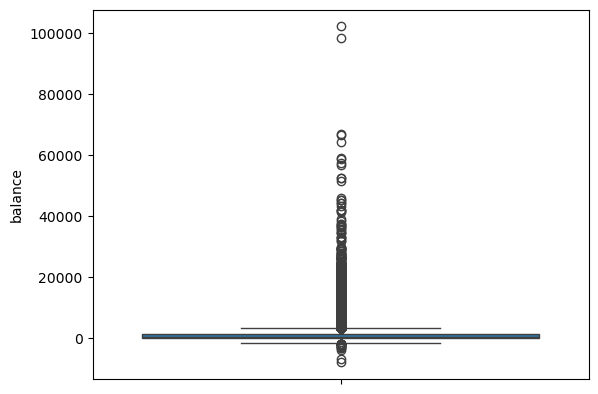

In [6]:
sns.boxplot(y=df['balance'])

<Axes: ylabel='age'>

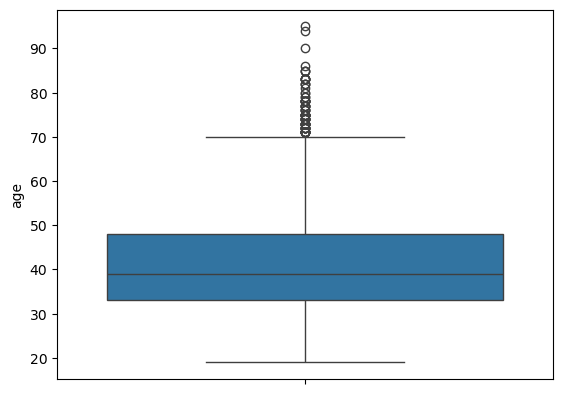

In [7]:
sns.boxplot(y=df['age'])

<Axes: ylabel='duration'>

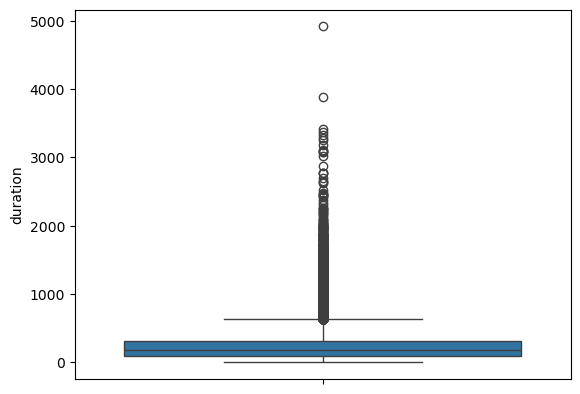

In [8]:
sns.boxplot(y=df['duration'])

<Axes: ylabel='campaign'>

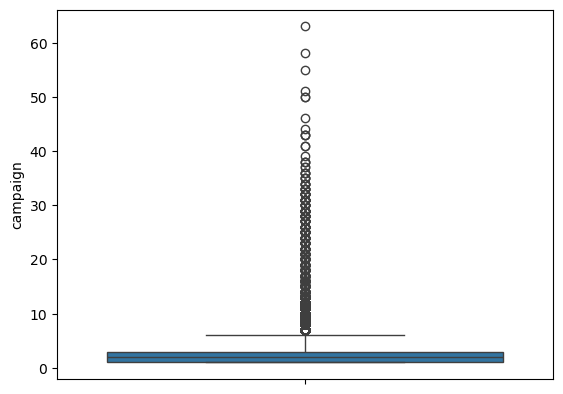

In [9]:
sns.boxplot(y=df['campaign'])

<Axes: ylabel='day'>

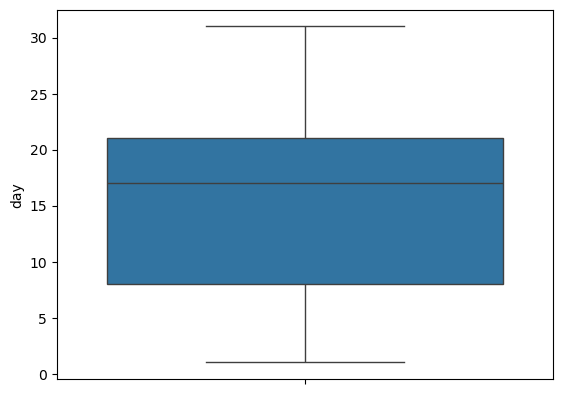

In [10]:
sns.boxplot(y=df['day'])

In [11]:
labels = []
for i in range(len(df)):
    if df['y'][i] == 'yes':
        labels.append(1)
    if df['y'][i] == 'no':
        labels.append(0)
y = pd.DataFrame(labels)
print(y)

       0
0      0
1      0
2      0
3      0
4      0
...   ..
39995  0
39996  1
39997  1
39998  0
39999  0

[40000 rows x 1 columns]


In [12]:
job_count_check = df.groupby(by='job')

job_count_check['y'].value_counts()

job            y  
admin          no     4132
               yes     351
blue-collar    no     8848
               yes     535
entrepreneur   no     1317
               yes      88
housemaid      no     1034
               yes      53
management     no     7490
               yes     676
retired        no     1286
               yes     151
self-employed  no     1302
               yes     112
services       no     3672
               yes     238
student        no      442
               yes      82
technician     no     6355
               yes     497
unemployed     no     1008
               yes      96
unknown        no      218
               yes      17
Name: count, dtype: int64

In [13]:
print(f'admin: {351/4132}', f'blue-collar: {535/8848}', f'entrepreneur: {88/1317}', 
      f'housemaid: {53/1034}', f'management: {676/7490}', f'retired: {151/1286}', f'self-employed: {112/1302}', 
f'services: {238/3672}', f'student: {82/442}', f'technician: {497/6355}', f'unemployed: {96/1008}', f'unknown: {17/218}')

admin: 0.08494675701839303 blue-collar: 0.06046564195298373 entrepreneur: 0.06681852695520121 housemaid: 0.05125725338491296 management: 0.09025367156208278 retired: 0.11741835147744946 self-employed: 0.08602150537634409 services: 0.06481481481481481 student: 0.18552036199095023 technician: 0.07820613690007867 unemployed: 0.09523809523809523 unknown: 0.0779816513761468


In [15]:
month_count_check = df.groupby(by='month')

month_count_check['y'].value_counts()

month  y  
apr    no      2267
       yes      451
aug    no      4927
       yes      288
dec    no        12
       yes        1
feb    no      2041
       yes      255
jan    no      1138
       yes       38
jul    no      5996
       yes      384
jun    no      4440
       yes      294
mar    no       133
       yes      125
may    no     12741
       yes      791
nov    no      3378
       yes      220
oct    yes       49
       no        31
Name: count, dtype: int64

In [16]:
print(f' apr: {451/2267}', f' aug:  {288/4927}', f' dec: {1/12}', f' feb: {255/2041}', f' jan: {38/1138}', 
f' jul: {384/5996}', f'jun: {294/4440}', f' mar: {125/133}', 
f'may: {791/12741}', f' nov: {220/3378}', f' oct: {31/49}')

 apr: 0.19894133215703572  aug:  0.05845341993099249  dec: 0.08333333333333333  feb: 0.12493875551200392  jan: 0.033391915641476276  jul: 0.06404269513008673 jun: 0.06621621621621622  mar: 0.9398496240601504 may: 0.062083039007927165  nov: 0.06512729425695678  oct: 0.6326530612244898


In [17]:
df.replace(to_replace='retired', value='not_working', inplace=True)
df.replace(to_replace='student', value='not_working', inplace=True)
df.replace(to_replace='unemployed', value='not_working', inplace=True)
df.replace(to_replace='blue-collar', value='working', inplace=True)
df.replace(to_replace='technician', value='working', inplace=True)
df.replace(to_replace='management', value='working', inplace=True)
df.replace(to_replace='admin', value='working', inplace=True)
df.replace(to_replace='entrepreneur', value='working', inplace=True)
df.replace(to_replace='housemaid', value='working', inplace=True)
df.replace(to_replace='self-employed', value='working', inplace=True)
df.replace(to_replace='services', value='working', inplace=True)
df['job'].value_counts()

job
working        36700
not_working     3065
unknown          235
Name: count, dtype: int64

In [18]:
df.replace(to_replace='mar', value='high_month', inplace=True)
df.replace(to_replace='oct', value='high_month', inplace=True)
df.replace(to_replace='apr', value='high_month', inplace=True)
df.replace(to_replace='feb', value='high_month', inplace=True)
df.replace(to_replace='jan', value='low_month', inplace=True)
df.replace(to_replace='may', value='low_month', inplace=True)
df.replace(to_replace='jun', value='low_month', inplace=True)
df.replace(to_replace='jul', value='low_month', inplace=True)
df.replace(to_replace='aug', value='low_month', inplace=True)
df.replace(to_replace='nov', value='low_month', inplace=True)
df.replace(to_replace='dec', value='low_month', inplace=True)
df['month'].value_counts()

month
low_month     34648
high_month     5352
Name: count, dtype: int64

In [19]:
x = df.drop(columns=['y'])

categorical_columns = x.select_dtypes(include=['object']).columns.tolist()

encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(x[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

x_encoded = pd.concat([x, one_hot_df], axis=1)
x_encoded = x_encoded.drop(categorical_columns, axis=1)
print(x_encoded.head())

   age  balance  day  duration  campaign  job_not_working  job_unknown  \
0   58     2143    5       261         1              0.0          0.0   
1   44       29    5       151         1              0.0          0.0   
2   33        2    5        76         1              0.0          0.0   
3   47     1506    5        92         1              0.0          0.0   
4   33        1    5       198         1              0.0          1.0   

   job_working  marital_divorced  marital_married  ...  default_yes  \
0          1.0               0.0              1.0  ...          0.0   
1          1.0               0.0              0.0  ...          0.0   
2          1.0               0.0              1.0  ...          0.0   
3          1.0               0.0              1.0  ...          0.0   
4          0.0               0.0              0.0  ...          0.0   

   housing_no  housing_yes  loan_no  loan_yes  contact_cellular  \
0         0.0          1.0      1.0       0.0               0

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=1)
model_basic = xgb.XGBClassifier()
model_basic.fit(x_train, y_train)
train_pred_basic = model_basic.fit(x_train, y_train)
y_pred_bin_basic = model_basic.predict(x_test)
train_pred_basic = model_basic.predict_proba(x_train)
y_pred_basic = model_basic.predict_proba(x_test)

positive_prob_basic = [sublist[1] for sublist in y_pred_basic]


print(len(positive_prob_basic))

8000


In [21]:
cv_scores = cross_val_score(model_basic, x_encoded, y, scoring='f1', cv=5)
print(cv_scores)

mae_cv = cv_scores.mean()
print(mae_cv)


[0.08250825 0.15088968 0.12718601 0.07495069 0.14926591]
0.1169601071596004


In [ ]:
search_space = {
    'eta': Real(0.01, 0.1),
    'base_score': Real(0.5, 0.9),
    'n_estimators': Integer(10, 15),
    'reg_lambda': Real(30, 40),
    'alpha': Real(30, 40),
    
    
}

bayes_search = BayesSearchCV(estimator=model_basic, scoring='f1', search_spaces=search_space, 
                             n_iter=160, cv=5, n_jobs=-1)
bayes_search.fit(x_encoded, y)
 
print(f"Best parameters: {bayes_search.best_params_}")
print(f"Best score: {bayes_search.best_score_}")

In [23]:
model_opt = xgb.XGBClassifier(alpha = 10.0, base_score = 0.6236061444514498, eta = 0.03044535118627982, gamma = 14, max_depth = 3, 
n_estimators = 10, reg_lambda = 10.0)
model_opt.fit(x_train, y_train)
train_pred = model_opt.fit(x_train, y_train)
y_pred_bin = model_opt.predict(x_test)
train_pred = model_opt.predict_proba(x_train)
y_pred = model_opt.predict_proba(x_test)

positive_prob = [sublist[1] for sublist in y_pred]


print(len(positive_prob))

8000


In [25]:
cv_scores = cross_val_score(model_opt, x_encoded, y, scoring='f1', cv=5)
print(cv_scores)

mae_cv = cv_scores.mean()
print(mae_cv)


[0.61854387 0.58616505 0.45345345 0.31909212 0.21792392]
0.43903568308908714


In [27]:
rus = RandomUnderSampler(sampling_strategy='majority')
X_resampled_down, y_resampled_down = rus.fit_resample(x_train, y_train)

#print(f"After Downsampling: {Counter(y_resampled_down)}")
y_resampled_down.value_counts()

/Users/leszekwierzchleyski/anaconda3/envs/myenv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/leszekwierzchleyski/anaconda3/envs/myenv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


0
0    2331
1    2331
Name: count, dtype: int64

In [28]:
model_basic_small = xgb.XGBClassifier()
model_basic_small.fit(X_resampled_down, y_resampled_down)
small_bin_pred = model_basic_small.predict(x_test)
model_basic_small.predict_proba(x_test)
sklearn.metrics.f1_score(y_test, small_bin_pred)

0.45405887600356826

In [ ]:
search_space = {
    'eta': Real(0.01, 0.1),
    'max_depth': Integer(10,20),
    'base_score': Real(0.1, 0.9),
    'n_estimators': Integer(25, 50),
    'reg_lambda': Real(0, 20),
    'alpha': Real(20, 30),
    'gamma': Real(0,20)
    
}

bayes_search = BayesSearchCV(estimator=model_basic_small, scoring='f1', search_spaces=search_space, 
                             n_iter=200, cv=5, n_jobs=-1)
bayes_search.fit(X_resampled_down, y_resampled_down)
 
print(f"Best parameters small: {bayes_search.best_params_}")
print(f"Best score small: {bayes_search.best_score_}")

In [29]:
model_small_opt = xgb.XGBClassifier(alpha = 20.0, base_score = 0.5784140505948373, eta = 0.08433993487263637, gamma = 0.0, 
                                    max_depth = 20, n_estimators = 50, reg_lambda = 0.0)
model_small_opt.fit(X_resampled_down, y_resampled_down)
small_opt_bin_pred = model_small_opt.predict(x_test)
small_opt_pred = model_small_opt.predict_proba(x_test)
small_positive_prob = [sublist[1] for sublist in small_opt_pred]
sklearn.metrics.f1_score(y_test, small_opt_bin_pred)

0.4583889630618603

In [30]:
percentage = 20 

n_rows = int(len(df) * (percentage / 100))



test_n_df = x.tail(n_rows).copy()
y_test_list = y.tail(n_rows).copy()
test_n_df= test_n_df.assign(Probabilities = small_positive_prob)

test_n_df= test_n_df.assign(y = y_test_list)
test_n_df= test_n_df.assign(Prediction = small_opt_bin_pred)
sorted_test_n_df = test_n_df.sort_values(by='Probabilities',   ascending=False)


print(sorted_test_n_df.head())

       age          job   marital  education default  balance housing loan  \
38160   33      working    single    primary      no      433     yes   no   
33706   74  not_working   married  secondary      no     9480      no   no   
33523   37      working   married   tertiary      no      489     yes  yes   
32873   32      working  divorced  secondary      no      453     yes   no   
38195   60      working  divorced  secondary      no      174     yes   no   

        contact  day       month  duration  campaign  Probabilities  y  \
38160  cellular   15   low_month        54         4       0.934068  0   
33706  cellular   21  high_month       211         1       0.934068  1   
33523  cellular   20  high_month        12         2       0.933963  0   
32873  cellular   17  high_month       329         1       0.933458  0   
38195  cellular   15   low_month       241         1       0.932843  0   

       Prediction  
38160           1  
33706           1  
33523           1  
32873 

In [31]:
percentage = 5 

n_rows = int(len(sorted_test_n_df) * (percentage / 100))


test_5_df = sorted_test_n_df.head(n_rows).copy()
sklearn.metrics.recall_score(test_5_df['y'], test_5_df['Prediction'])

1.0

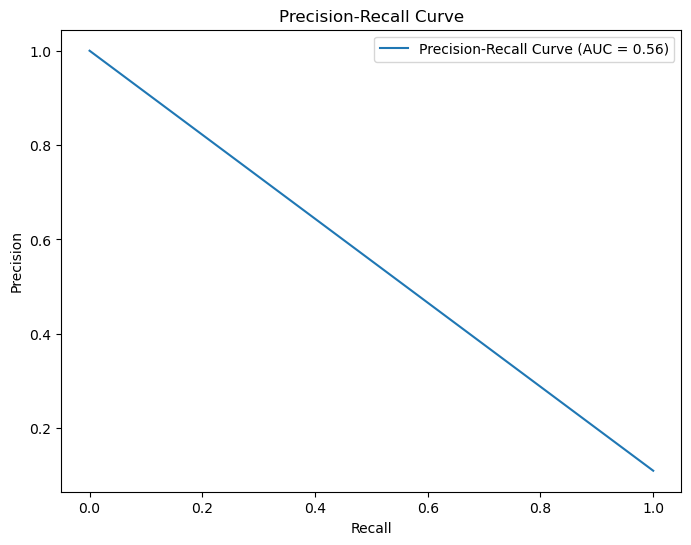

In [32]:
precision, recall, thresholds = precision_recall_curve(test_5_df['y'],test_5_df['Prediction'])
auc_score = auc(recall, precision)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [34]:
percentage = 10 

n_rows = int(len(sorted_test_n_df) * (percentage / 100))


test_10_df = sorted_test_n_df.head(n_rows).copy()
sklearn.metrics.recall_score(test_10_df['y'], test_10_df['Prediction'])

1.0

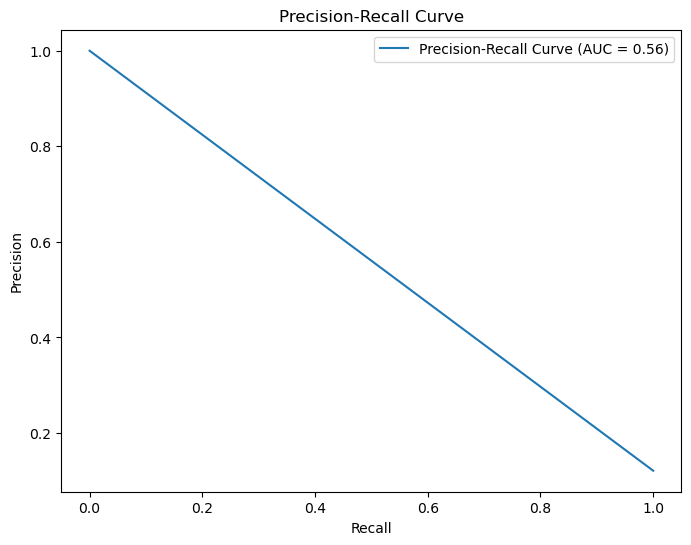

In [35]:
precision, recall, thresholds = precision_recall_curve(test_10_df['y'],test_10_df['Prediction'])
auc_score = auc(recall, precision)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [36]:
percentage = 20 

n_rows = int(len(sorted_test_n_df) * (percentage / 100))


test_20_df = sorted_test_n_df.head(n_rows).copy()
sklearn.metrics.recall_score(test_20_df['y'], test_20_df['Prediction'])

1.0

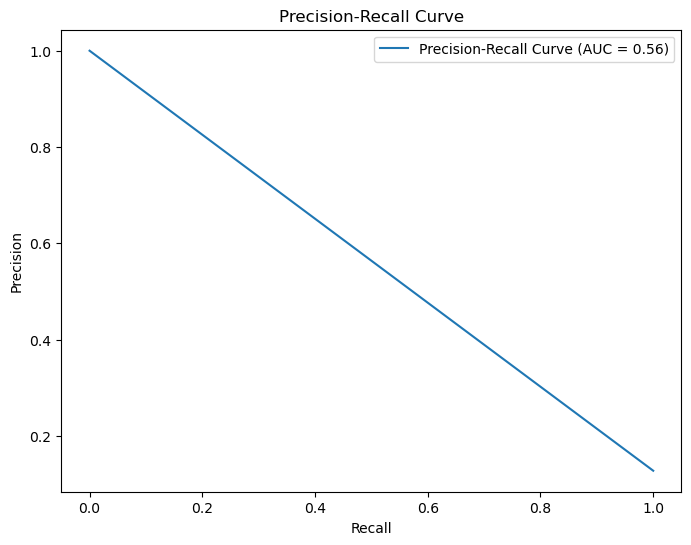

In [37]:
precision, recall, thresholds = precision_recall_curve(test_20_df['y'],test_20_df['Prediction'])
auc_score = auc(recall, precision)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [38]:
percentage = 30 

n_rows = int(len(sorted_test_n_df) * (percentage / 100))


test_30_df = sorted_test_n_df.head(n_rows).copy()
sklearn.metrics.recall_score(test_30_df['y'], test_30_df['Prediction'])

0.6990291262135923

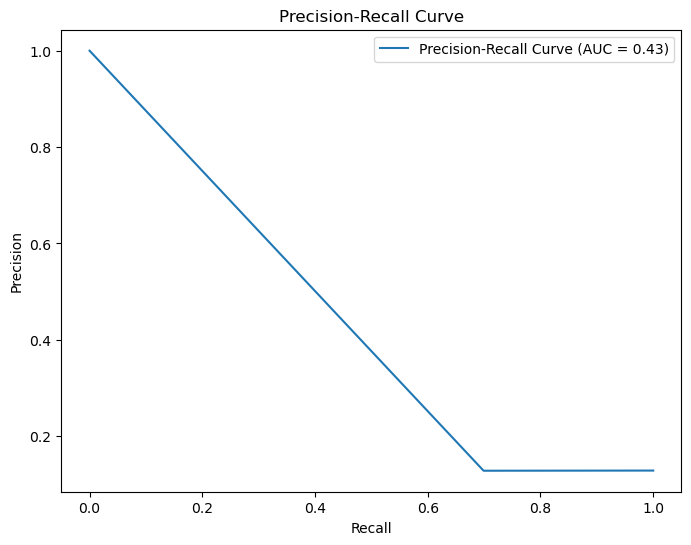

In [39]:
precision, recall, thresholds = precision_recall_curve(test_30_df['y'],test_30_df['Prediction'])
auc_score = auc(recall, precision)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

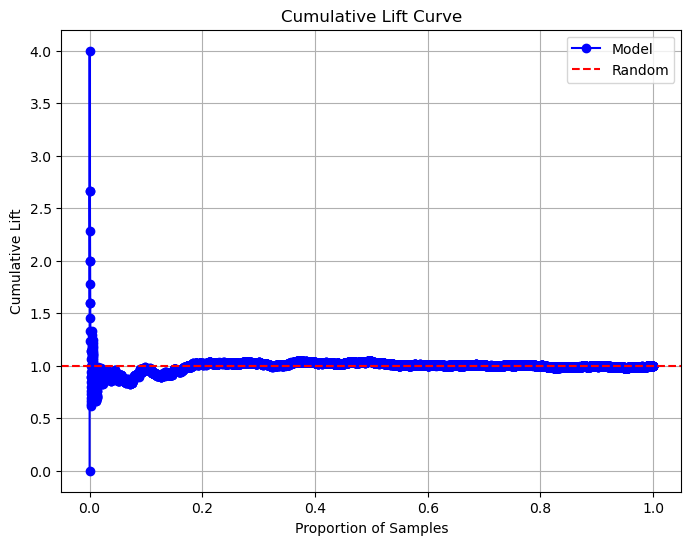

In [40]:
n = len(sorted_test_n_df['y']) 

cumulative_positive = np.cumsum(sorted_test_n_df['y'])
    
    
cumulative_positive_percentage = cumulative_positive / np.arange(1, n + 1)


    
overall_positive_percentage = np.sum(sorted_test_n_df['y']) / n
    
cumulative_lifts = cumulative_positive_percentage / overall_positive_percentage

plt.figure(figsize=(8, 6))
plt.plot(np.arange(1, len(sorted_test_n_df['y']) + 1) / len(sorted_test_n_df['y']), cumulative_lifts, marker='o', linestyle='-', color='b')
plt.axhline(y=1, color='red', linestyle='--')
plt.xlabel('Proportion of Samples')
plt.ylabel('Cumulative Lift')
plt.title('Cumulative Lift Curve')
plt.legend(['Model', 'Random'])
plt.grid(True)
plt.show()

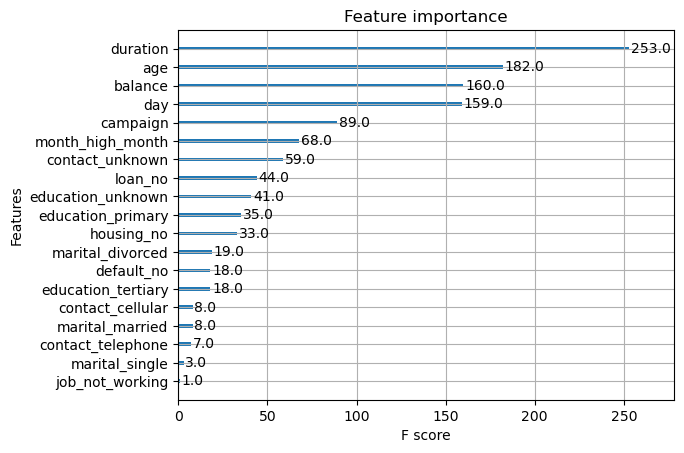

In [41]:
plot_importance(model_small_opt)
plt.show()

<Axes: ylabel='balance'>

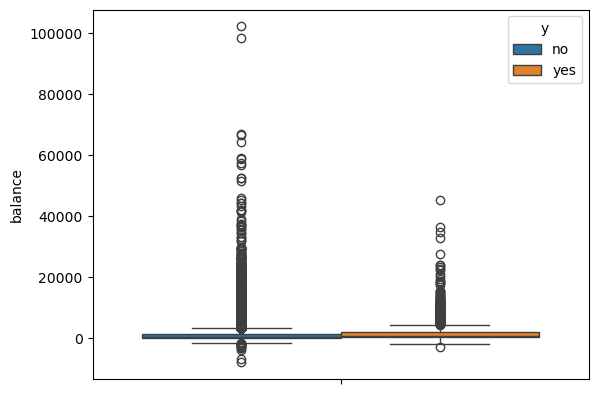

In [42]:
sns.boxplot(y=df['balance'], hue=df['y'])

<Axes: ylabel='age'>

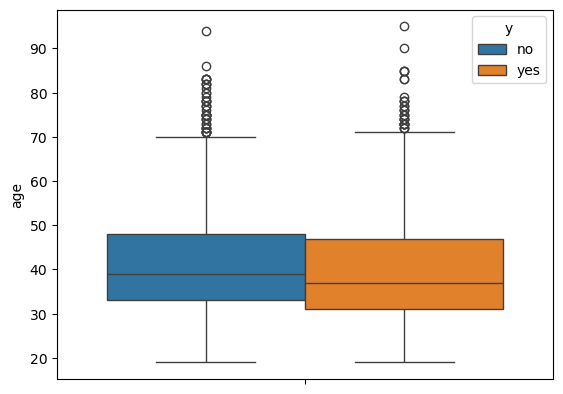

In [43]:
sns.boxplot(y=df['age'], hue=df['y'])

<Axes: ylabel='day'>

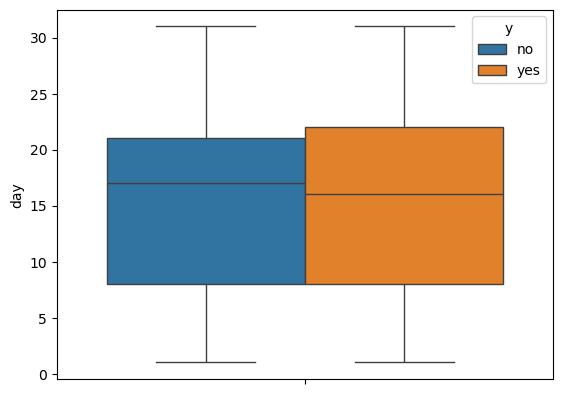

In [44]:
sns.boxplot(y=df['day'], hue=df['y'])

In [45]:
x_WO_dur = x_encoded
x_WO_dur.drop(columns=['duration'], axis=1, inplace=True)

In [46]:
x_train_dur, x_test_dur, y_train_dur, y_test_dur = train_test_split(x_WO_dur, y, test_size=0.2, random_state=1)

In [47]:
rus = RandomUnderSampler(sampling_strategy='majority')
X_resampled_down_dur, y_resampled_down_dur = rus.fit_resample(x_train_dur, y_train_dur)

#print(f"After Downsampling: {Counter(y_resampled_down)}")
y_resampled_down_dur.value_counts()

/Users/leszekwierzchleyski/anaconda3/envs/myenv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/leszekwierzchleyski/anaconda3/envs/myenv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


0
0    2331
1    2331
Name: count, dtype: int64

In [49]:
model_basic_small_dur = xgb.XGBClassifier()
model_basic_small_dur.fit(X_resampled_down_dur, y_resampled_down_dur)
small_basic_bin_pred_dur = model_basic_small_dur.predict(x_test_dur)
small_basic_prob_dur = model_basic_small_dur.predict_proba(x_test_dur)
small_basic_positive_prob_dur = [sublist[1] for sublist in small_basic_prob_dur]
sklearn.metrics.f1_score(y_test_dur, small_basic_bin_pred_dur)

0.18345127925966248

In [ ]:
search_space = {
    'eta': Real(0.01, 0.1),
    'max_depth': Integer(10,20),
    'base_score': Real(0.1, 0.9),
    'n_estimators': Integer(25, 50),
    'reg_lambda': Real(0, 20),
    'alpha': Real(20, 30),
    'gamma': Real(0,20)
    
}

bayes_search_dur = BayesSearchCV(estimator=model_basic_small_dur, scoring='f1', search_spaces=search_space, 
                             n_iter=100, cv=5, n_jobs=-1, verbose=1)
bayes_search_dur.fit(X_resampled_down_dur, y_resampled_down_dur)
 
print(f"Best parameters small dur: {bayes_search_dur.best_params_}")
print(f"Best score small dur: {bayes_search_dur.best_score_}")

In [50]:
model_basic_small_dur_opt = xgb.XGBClassifier(alpha= 30.0, base_score = 0.9, eta = 0.05304199026716386, gamma = 0.0, max_depth = 20, 
                                              n_estimators = 32, reg_lambda = 20.0)
model_basic_small_dur_opt.fit(X_resampled_down_dur, y_resampled_down_dur)
small_bin_pred_dur_opt = model_basic_small_dur_opt.predict(x_test_dur)
small_prob_dur = model_basic_small_dur_opt.predict_proba(x_test_dur)
small_positive_prob_dur = [sublist[1] for sublist in small_prob_dur]
sklearn.metrics.f1_score(y_test_dur, small_bin_pred_dur_opt)

0.1514391143911439

In [51]:
percentage = 20 

n_rows = int(len(df) * (percentage / 100))



test_n_df_dur = x_WO_dur.tail(n_rows).copy()
y_test_list = y.tail(n_rows).copy()
test_n_df_dur = test_n_df_dur.assign(Prob = small_positive_prob_dur)

test_n_df_dur = test_n_df_dur.assign(y = y_test_list)
test_n_df_dur = test_n_df_dur.assign(Prediction = small_bin_pred_dur_opt)
sorted_test_n_df_dur = test_n_df_dur.sort_values(by='Prob',   ascending=False)


print(sorted_test_n_df_dur)

       age  balance  day  campaign  job_not_working  job_unknown  job_working  \
38581   44      532   15         2              0.0          0.0          1.0   
36331   34      213   11         1              0.0          0.0          1.0   
33618   35     1257   20         3              0.0          0.0          1.0   
37563   47      120   14         6              0.0          0.0          1.0   
36474   35      847   11         2              0.0          0.0          1.0   
...    ...      ...  ...       ...              ...          ...          ...   
33178   28      335   20         3              0.0          0.0          1.0   
37849   25      938   14         1              1.0          0.0          0.0   
35358   45        0    7         1              0.0          0.0          1.0   
35367   43     1234    7         1              0.0          0.0          1.0   
32000   29       84   13         2              0.0          0.0          1.0   

       marital_divorced  ma

In [52]:
percentage = 5 

n_rows = int(len(sorted_test_n_df_dur) * (percentage / 100))


test_5_df_dur = sorted_test_n_df_dur.head(n_rows).copy()
sklearn.metrics.recall_score(test_5_df_dur['y'], test_5_df_dur['Prediction'])

1.0

In [53]:
percentage = 10 

n_rows = int(len(sorted_test_n_df_dur) * (percentage / 100))


test_10_df_dur = sorted_test_n_df_dur.head(n_rows).copy()
sklearn.metrics.recall_score(test_10_df_dur['y'], test_10_df_dur['Prediction'])

1.0

In [54]:
percentage = 20 

n_rows = int(len(sorted_test_n_df_dur) * (percentage / 100))


test_20_df_dur = sorted_test_n_df_dur.head(n_rows).copy()
sklearn.metrics.recall_score(test_20_df_dur['y'], test_20_df_dur['Prediction'])

1.0